Iter  | x1       | x2       | h(x)     | g(x)     | rho  
-----------------------------------------------------------------
0     | 0.8542   | 0.8070   | -0.0773  | 0.1613   | 10.0 
1     | 0.8254   | 0.6897   | -0.0084  | 0.0151   | 10.0 
2     | 0.8231   | 0.6783   | -0.0008  | 0.0014   | 10.0 
3     | 0.8229   | 0.6772   | -0.0001  | 0.0001   | 10.0 
4     | 0.8229   | 0.6771   | -0.0000  | 0.0000   | 10.0 
5     | 0.8229   | 0.6771   | -0.0000  | 0.0000   | 10.0 

✅ 算法已收敛到可行最优解。

最终最优解: x* = [0.82287775 0.67713554]
目标函数最小值: f(x*) = 1.781343


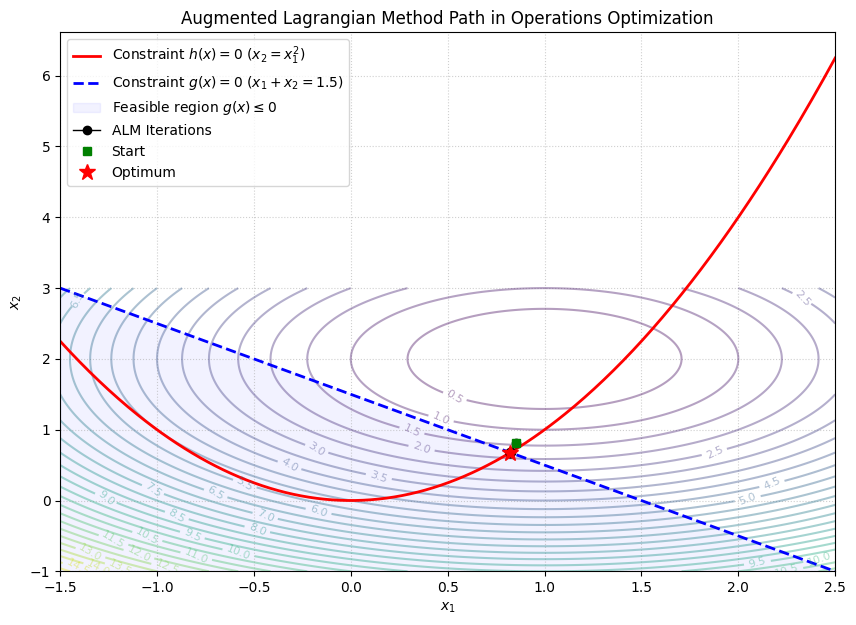

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================
# 1. 定义优化问题 (运筹优化模型)
# ==========================================

def objective(x):
    """目标函数: 最小化到点 (1, 2) 的距离平方"""
    return (x[0] - 1)**2 + (x[1] - 2)**2

def eq_constraint(x):
    """等式约束 h(x) = 0: 必须在抛物线 x2 = x1^2 上"""
    return x[0]**2 - x[1]

def ineq_constraint(x):
    """不等式约束 g(x) <= 0: 必须在直线 x1 + x2 <= 1.5 的下方"""
    return x[0] + x[1] - 1.5

# ==========================================
# 2. 构造增广拉格朗日函数 (ALM Core)
# ==========================================

def augmented_lagrangian(x, lam, mu, rho):
    """
    计算增广拉格朗日函数值
    L(x, λ, μ, ρ) = f(x) + λ*h(x) + (ρ/2)*h(x)^2 + (1/2ρ) * [max(0, μ + ρ*g(x))^2 - μ^2]
    """
    # 目标函数项
    f_val = objective(x)

    # 等式约束项 (Quadratic Penalty + Multiplier)
    h_val = eq_constraint(x)
    eq_term = lam * h_val + (rho / 2.0) * h_val**2

    # 不等式约束项 (PHR - Powell-Hestenes-Rockafellar 形式)
    g_val = ineq_constraint(x)
    # 使用 max(0, mu + rho * g) 来处理不等式的转换
    penalty_g = np.maximum(0, mu + rho * g_val)
    ineq_term = (1.0 / (2.0 * rho)) * (penalty_g**2 - mu**2)

    return f_val + eq_term + ineq_term

# ==========================================
# 3. ALM 算法主迭代循环
# ==========================================

def solve_alm(max_iter=10, tol=1e-5):
    # 初始参数设置
    x = np.array([0.0, 0.0])  # 初始决策变量
    lam = 0.0                 # 等式约束乘子初始值
    mu = 0.0                  # 不等式约束乘子初始值
    rho = 10.0                # 罚参数

    history = []

    print(f"{'Iter':<5} | {'x1':<8} | {'x2':<8} | {'h(x)':<8} | {'g(x)':<8} | {'rho':<5}")
    print("-" * 65)

    for k in range(max_iter):
        # --- 步骤 A: 求解无约束子问题 ---
        # 固定 lam, mu, rho，寻找使 L 最小的 x
        res = minimize(augmented_lagrangian, x, args=(lam, mu, rho), method='BFGS')
        x_new = res.x

        h_val = eq_constraint(x_new)
        g_val = ineq_constraint(x_new)

        # 记录迭代轨迹
        history.append({'x': x_new, 'h': h_val, 'g': g_val})

        print(f"{k:<5} | {x_new[0]:<8.4f} | {x_new[1]:<8.4f} | {h_val:<8.4f} | {g_val:<8.4f} | {rho:<5.1f}")

        # --- 步骤 B: 检查收敛条件 ---
        violation = max(abs(h_val), max(0, g_val))
        if violation < tol:
            print("\n✅ 算法已收敛到可行最优解。")
            break

        # --- 步骤 C: 更新拉格朗日乘子 (Dual Update) ---
        lam = lam + rho * h_val
        mu = np.maximum(0, mu + rho * g_val)

        # --- 步骤 D: 更新罚参数 (可选策略) ---
        # 如果约束改进不够快，则增加 rho 以加强约束惩罚
        # rho *= 1.2

        x = x_new

    return x, history

# ==========================================
# 4. 可视化结果
# ==========================================

def visualize_results(history):
    x1 = np.linspace(-1.5, 2.5, 400)
    x2 = np.linspace(-1, 3, 400)
    X1, X2 = np.meshgrid(x1, x2)

    # 目标函数等高线
    Z = (X1 - 1)**2 + (X2 - 2)**2

    plt.figure(figsize=(10, 7))
    cp = plt.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.4)
    plt.clabel(cp, inline=True, fontsize=8)

    # 绘制约束边界
    plt.plot(x1, x1**2, 'r-', linewidth=2, label=r'Constraint $h(x)=0$ ($x_2=x_1^2$)')
    plt.plot(x1, 1.5 - x1, 'b--', linewidth=2, label=r'Constraint $g(x)=0$ ($x_1+x_2=1.5$)')
    plt.fill_between(x1, -1, 1.5 - x1, color='blue', alpha=0.05, label='Feasible region $g(x) \leq 0$')

    # 绘制迭代路径
    hist_x = np.array([h['x'] for h in history])
    plt.plot(hist_x[:, 0], hist_x[:, 1], 'ko-', markersize=6, linewidth=1, label='ALM Iterations')
    plt.plot(hist_x[0, 0], hist_x[0, 1], 'gs', label='Start')
    plt.plot(hist_x[-1, 0], hist_x[-1, 1], 'r*', markersize=12, label='Optimum')

    plt.title('Augmented Lagrangian Method Path in Operations Optimization')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# 运行求解
if __name__ == "__main__":
    best_x, path = solve_alm()
    print(f"\n最终最优解: x* = {best_x}")
    print(f"目标函数最小值: f(x*) = {objective(best_x):.6f}")
    visualize_results(path)

## 增广拉格朗日法 (ALM) 总结

在**运营优化**中，我们经常需要处理带约束的非线性问题。

### 目标函数与约束
$$\min_{x} f(x) = (x_1 - 1)^2 + (x_2 - 2)^2$$
满足：
* $h(x) = x_1^2 - x_2 = 0$
* $g(x) = x_1 + x_2 - 1.5 \leq 0$

### 增广拉格朗日构造
我们构造函数 $\mathcal{L}_{\rho}(x, \lambda, \mu)$：
$$\mathcal{L}_{\rho} = f(x) + \lambda h(x) + \frac{\rho}{2} h(x)^2 + \text{Penalty}(g(x), \mu, \rho)$$

其中乘子更新逻辑为：
1. $\lambda \leftarrow \lambda + \rho h(x)$
2. $\mu \leftarrow \max(0, \mu + \rho g(x))$